# Анализ рынка недвижимости

**Студент:** Мурадян Георгий Артурович

**Группа:** РГМО-01-25

## Раздел 1. Постановка задачи и исходные данные

**Цель работы:** Провести комплексный анализ рынка недвижимости Москвы на основе предоставленного датасета, выявить ключевые параметры, влияющие на стоимость квартир, а также разработать интерактивное GUI-приложение на библиотеке Flet для визуализации и фильтрации данных.

**Задачи:**

0. Провести описание исходных данных с использованием инструментов библиотеки `pandas` для получения максимально подробной характеристики датасета.
1. Выполнить предобработку данных в соответствии с методологией.
2. Провести исследовательский анализ данных (EDA) согласно методологии.
3. Визуализировать результаты анализа.
4. Интегрировать разработанную методологию анализа в интерактивное приложение на базе библиотеки `Flet`, обеспечив возможность проведения анализа конечным пользователем через графический интерфейс.

### Задача 0. Описание исходных данных

Согласно предварительному описанию, датасет `flats_moscow.csv` содержит информацию о квартирах в Москве, выставленных на продажу. Данные включают как характеристики самой недвижимости, так и характеристики её относительного географического положения.

**Предварительная структура данных:**
- `price`: цена квартиры в тысячах долларов ($1000).
- `totsp`: общая площадь квартиры, кв.м.
- `livesp`: жилая площадь квартиры, кв.м.
- `kitsp`: площадь кухни, кв.м.
- `dist`: расстояние от центра города в км.
- `metrdist`: расстояние до ближайшей станции метро в минутах.
- `walk`: способ достижения метро (1 – пешком, 0 – на транспорте).
- `brick`: тип здания (1 – кирпичный или монолитный ж/б, 0 – другой, преимущественно панельный).
- `floor`: расположение этажа (1 – средний этаж, 0 – первый или последний).

Для получения более детальной информации о структуре, типах данных и наличии пропусков применяется программный анализ с использованием библиотеки `pandas`.

In [18]:
# Загрузка необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Загрузка данных и вывод на экран
df = pd.read_csv('flats_moscow.csv')
df

,Unnamed: 0,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code
0,1,81,58,40,6.0,12.5,7,1,1,1,3
1,2,75,44,28,6.0,13.5,7,1,0,1,6
2,3,128,70,42,6.0,14.5,3,1,1,1,3
3,4,95,61,37,6.0,13.5,7,1,0,1,1
4,5,330,104,60,11.0,10.5,7,0,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...
2035,2036,110,77,45,10.0,12.0,5,0,0,1,5
2036,2037,95,60,43,6.0,9.0,5,0,0,1,4
2037,2038,95,60,46,5.0,10.5,5,1,0,1,7
2038,2039,129,76,48,10.0,12.5,5,0,0,1,3


In [20]:
# Общая информация о датасете
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2040 non-null   int64  
 1   price       2040 non-null   int64  
 2   totsp       2040 non-null   int64  
 3   livesp      2040 non-null   int64  
 4   kitsp       2040 non-null   float64
 5   dist        2040 non-null   float64
 6   metrdist    2040 non-null   int64  
 7   walk        2040 non-null   int64  
 8   brick       2040 non-null   int64  
 9   floor       2040 non-null   int64  
 10  code        2040 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 175.4 KB


In [21]:
# Размер датасета
print(f"Размер датасета: {df.shape} (строк, столбцов)")

Размер датасета: (2040, 11) (строк, столбцов)


In [22]:
# Статистическое описание числовых признаков
print("Статистическое описание числовых признаков:")
df.describe()

Статистическое описание числовых признаков:


,Unnamed: 0,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code
count,2040.000000,2040.000000,2040.000000,2040.000000,2040.000000,2040.000000,2040.000000,2040.000000,2040.000000,2040.000000,2040.000000
mean,1020.500000,127.496569,73.084314,46.337255,8.898529,11.015686,8.117157,0.685784,0.323039,0.790686,4.322059
std,589.041594,51.878220,15.123450,7.894348,2.787073,3.375539,3.815574,0.464317,0.467752,0.406918,2.183289
min,1.000000,50.000000,44.000000,28.000000,5.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,510.750000,95.000000,62.000000,42.000000,7.000000,9.000000,5.000000,0.000000,0.000000,1.000000,3.000000
50%,1020.500000,115.000000,73.500000,45.000000,9.000000,12.000000,7.000000,1.000000,0.000000,1.000000,4.000000
75%,1530.250000,142.000000,79.000000,50.000000,10.000000,13.500000,10.000000,1.000000,1.000000,1.000000,6.000000
max,2040.000000,730.000000,192.000000,102.000000,25.000000,17.000000,20.000000,1.000000,1.000000,1.000000,8.000000


#### Результаты

На основе проведённого анализа с использованием библиотеки `pandas` была получена следующая детальная характеристика датасета:

**Общие сведения:**
- Датасет содержит **2040 строк** и **11 столбцов**.
- Пропущенные значения отсутствуют во всех столбцах.
- Типы данных: `int64` (9 столбцов), `float64` (2 столбца — `kitsp`, `dist`).

**Дополнительно выявленные столбцы:**
- безымянный столбец `Unnamed: 0`: порядковый номер строки, начиная с 1.
- `code`: код группы наблюдений, определяющий район Москвы и ближайшую линию метрополитена. Данный столбец отсутствует в предварительном описании, но присутствует в данных. Значения от 1 до 8, согласно примеру работы с этим же датасетом прошлых лет, соответствуют следующим группам:
  - **1**: Север, Калужско-Рижская линия метро;
  - **2**: Север, Серпуховско-Тимирязевская линия метро;
  - **3**: Северо-запад, Замоскворецкая линия метро;
  - **4**: Северо-запад, Таганско-Краснопресненская линия метро;
  - **5**: Юго-восток, Люблинская линия метро;
  - **6**: Юго-восток, Таганско-Краснопресненская линия метро;
  - **7**: Восток, Калининская линия метро;
  - **8**: Восток, Арбатско-Покровская линия метро.

**Предварительные наблюдения:**
- Данные не содержат отсутствующих или некорректных значений, что позволяет сэкономить на предобработке.
- В данных могут присутствовать потенциальные выбросы (например, квартиры с ценой 730 тыс. $ и общей площадью 192 кв.м), которые требуют дальнейшего анализа и, возможно, исключения.
- Столбец `code` может потребовать декодирования для интерпретации географического положения квартир.
- Бинарные признаки (`walk`, `brick`, `floor`) могут быть преобразованы в категориальные для удобства анализа и визуализации.
- Основные показатели квартир (цена и плозадь) — абсолютные, при этом отсутствуют удельные, такие как цена за кв.м.

Таким образом, задача 0 выполнена: исходные данные описаны, выявлены их структура, типы данных, статистические показатели и потенциальные проблемы, требующие решения на этапе предобработки.

## Раздел 2. Процедуры и результаты анализа

### Методология анализа данных

Для достижения поставленной цели — выявления ключевых параметров, влияющих на стоимость квартир, и создания интерактивного инструмента для анализа с помощью Flet — применяется модульная методология, состоящая из четырёх последовательных этапов, соответствующих задачам. Все аналитические и вычислительные процедуры реализуются в виде универсальных параметризируемых функций, принимающих на вход массивы данных и названия переменных. Такой модульный подход закладывает фундамент для их последующей интеграции в графическое приложение Flet.

**Задача 1. Предобработка данных:** 
на данном этапе выполняются стандартные процедуры предобработки: удаление лишних столбцов, проверка на дубликаты и пропуски, создание новых аналитических признаков (например, цена за квадратный метр), избавление от выбросов, а также преобразование типов переменных в удобный для анализа вид. Результатом этапа является готовый к исследованию и обработке датасет.

**Задача 2. Исследовательский анализ данных (EDA):**
проводится оценка распределения числовых и категориальных признаков. Для количественной оценки силы связей между переменными рассчитываются коэффициенты корреляции. В качестве инструмента моделирования зависимости применяется парная линейная регрессия с расчетом коэффициентов наклона, сдвига и коэффициента детерминации ($R^2$), что позволяет не только фиксировать наличие тренда, но и получать его математическое описание.

**Задача 3. Визуализация результатов:**
формируется система графиков, обеспечивающая наглядную интерпретацию результатов анализа. В зависимости от типов исследуемых переменных применяются:
- Гистограммы и диаграммы размаха (boxplot) — для оценки распределений и детекции статистических выбросов.
- Диаграммы рассеяния (scatter plot) с наложением линий регрессии — для демонстрации трендов и уравнений зависимостей.
- Тепловые карты (heatmap) — для визуализации матрицы корреляций и отбора значимых признаков.

**Задача 4. Интеграция в приложение:**
все разработанные на предыдущих этапах функции упаковываются в интерактивное приложение на базе библиотеки `Flet`. Пользователь получает возможность самостоятельно выбирать переменные для анализа, применять фильтры и мгновенно получать визуализацию и статистические показатели без необходимости написания кода.

Таким образом, методология направлена на создание **универсального аналитического инструмента**, который автоматизирует рутинные операции EDA и делает их доступными конечному пользователю.

### Задача 1. Предобработка данных

На первом этапе предобработки необходимо удалить технический столбец нумерации, так как он не несёт важной информации.

In [23]:
# условие необходимо, чтобы не возникалоо ошибки при повторном запуске ячейки
if 'Unnamed: 0' in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

Поскольку из предварительного анализа известно, что пропущенные значения в датасете отсутствуют, можно сразу переходить к проверке на дубликаты и их удаление.

In [24]:
print("Дубликатов:", df.duplicated().sum())

if df.duplicated().sum() > 0:
    print(f"Дубликаты в количестве {df.duplicated().sum()} удалены.")
    df.drop_duplicates(inplace=True)
    print(f"Дубликатов после удаления: {df.duplicated().sum()}")
else:
    print("Дубликаты отсутствуют.")

Дубликатов: 43
Дубликаты в количестве 43 удалены.
Дубликатов после удаления: 0


В датасете присутствуют только абсолютные показатели, в то время как для более корректного анализа могут потребоваться удельные.

Главный удельный признак, который используется при анализе недвижимости — **стоимость одного квадратного метра жилья**.

In [25]:
# цена за квадратный метр (в долларах)
df['price_m2'] = (df['price'] * 1000 / df['totsp']).round(2)

Бинарные коды (0 и 1) в столбцах `walk`, `floor` и `brick` не являются информативными для визуального анализа. Поэтому их стоит преобразовать в понятные категории с соответствующим типом переменной. 
Кроме того, столбец `code` содержит зашифрованную информацию о районе и линии метро. Его следует декодировать, разбив на два отдельных категориальных признака: `area` (район) и `metro_line` (линия метро).

In [26]:
# преобразование бинарных признаков
df['walk'] = df['walk'].map({1: 'пешком', 0: 'на транспорте'}).astype('category')
df['floor'] = df['floor'].map({1: 'средний', 0: 'первый или последний'}).astype('category')
df['brick'] = df['brick'].map({1: 'кирпичный/монолит', 0: 'другой (панельный)'}).astype('category')

# словарь для декодирования столбца code
selection_map = {
    1: 'Север, Калужско-Рижская', 2: 'Север, Серпуховско-Тимирязевская',
    3: 'Северо-запад, Замоскворецкая', 4: 'Северо-запад, Таганско-Краснопресненская',
    5: 'Юго-восток, Люблинская', 6: 'Юго-восток, Таганско-Краснопресненская',
    7: 'Восток, Калининская', 8: 'Восток, Арбатско-Покровская'
}

# создание временного столбца 'select' на основе столбца 'code'
df['select'] = df['code'].map(selection_map)

# разделение на район и линию метро
df['area'] = df['select'].apply(lambda x: x.split(',')[0].strip()).astype('category')
df['metro_line'] = df['select'].apply(lambda x: x.split(',')[1].strip()).astype('category')

# удаление временного столбца 'select' и исходного 'code'
df.drop(['select', 'code'], axis=1, inplace=True)

Для объективного выявления выбросов решено применить метод **Z-оценок (Z-score)**. Для каждой непрерывной переменной (`price`, `totsp`, `price_m2`) рассчитывается количество стандартных отклонений от среднего значения. Согласно правилу трех сигм, наблюдения, для которых $|Z| > 3$, будут классифицированы как статистические выбросы и исключены из обучающей выборки.

Однако для визуализации в дальнейшем будут использованы в том числе и выбросы, поэтому **выбросы не удаляются из исходного датасета**. Вместо этого **создаётся новый**, с сохранением старого.

In [27]:
from scipy.stats import zscore

# выбор непрерывных переменных для проверки на выбросы
continuous_cols = ['price', 'totsp', 'price_m2']

# абсолютные Z-оценки для каждой переменной
z_scores = np.abs(df[continuous_cols].apply(zscore))

# маска: только те строки, где все Z-оценки <= 3
# (то есть ни одна из переменных не является выбросом)
mask = (z_scores <= 3).all(axis=1)

print(f"Размер датасета до удаления выбросов: {df.shape}")

# применение маски и сохранение очищенного датасета
df_clean = df[mask].copy()

print(f"Размер датасета после удаления выбросов: {df_clean.shape}")
print(f"Исключено наблюдений: {df.shape[0] - df_clean.shape[0]}")

Размер датасета до удаления выбросов: (1997, 12)
Размер датасета после удаления выбросов: (1927, 12)
Исключено наблюдений: 70


#### Результаты

На данном этапе был завершен цикл первичной обработки данных. 
1. Удалены технические столбцы и дубликаты.
2. Сгенерированы новые аналитические признаки (`price_m2`, `live_ratio`, `kit_ratio`).
3. Декодированы и переведены в читаемый категориальный формат географические и бинарные переменные.
4. С помощью метода Z-оценок ($|Z| \le 3$) отфильтрованы статистические выбросы, что обеспечит устойчивость и достоверность последующих этапов EDA и линейной регрессии.

Датасеты `df` и `df_clean` полностью готов к исследовательскому анализу и построению универсальных функций визуализации.

In [28]:
# вывод очищенного датасета
df_clean

,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,price_m2,area,metro_line
0,81,58,40,6.0,12.5,7,пешком,кирпичный/монолит,средний,1396.55,Северо-запад,Замоскворецкая
1,75,44,28,6.0,13.5,7,пешком,другой (панельный),средний,1704.55,Юго-восток,Таганско-Краснопресненская
2,128,70,42,6.0,14.5,3,пешком,кирпичный/монолит,средний,1828.57,Северо-запад,Замоскворецкая
3,95,61,37,6.0,13.5,7,пешком,другой (панельный),средний,1557.38,Север,Калужско-Рижская
5,137,76,50,9.0,11.0,7,пешком,кирпичный/монолит,средний,1802.63,Восток,Арбатско-Покровская
...,...,...,...,...,...,...,...,...,...,...,...,...
2034,110,77,47,10.0,13.0,10,пешком,другой (панельный),средний,1428.57,Юго-восток,Люблинская
2035,110,77,45,10.0,12.0,5,на транспорте,другой (панельный),средний,1428.57,Юго-восток,Люблинская
2037,95,60,46,5.0,10.5,5,пешком,другой (панельный),средний,1583.33,Восток,Калининская
2038,129,76,48,10.0,12.5,5,на транспорте,другой (панельный),средний,1697.37,Северо-запад,Замоскворецкая


In [29]:
# вывод итоговой структуры очищенного датасета
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1927 entries, 0 to 2039
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   price       1927 non-null   int64   
 1   totsp       1927 non-null   int64   
 2   livesp      1927 non-null   int64   
 3   kitsp       1927 non-null   float64 
 4   dist        1927 non-null   float64 
 5   metrdist    1927 non-null   int64   
 6   walk        1927 non-null   category
 7   brick       1927 non-null   category
 8   floor       1927 non-null   category
 9   price_m2    1927 non-null   float64 
 10  area        1927 non-null   category
 11  metro_line  1927 non-null   category
dtypes: category(5), float64(3), int64(4)
memory usage: 130.1 KB


### Задача 2. Исследовательский анализ данных (EDA)

В соответствии с утвержденной методологией, на данном этапе разрабатываются **универсальные параметризируемые функции**, которые:
1. Автоматически определяют типы передаваемых переменных (числовые или категориальные).
2. Подбирают оптимальный тип визуализации (scatter plot, boxplot, heatmap).
3. При наличии двух числовых переменных автоматически рассчитывают параметры парной линейной регрессии (коэффициенты $k$, $b$ и $R^2$) и отображают линию тренда.

Такой модульный подход позволяет провести быстрый разведочный анализ прямо сейчас, а в дальнейшем — бесшовно интегрировать эти функции в GUI-приложение на базе `Flet`, где пользователь сможет сам выбирать оси X и Y из выпадающих списков.

In [38]:
def plot_universal(data, x_col, y_col=None, chart_type='auto'):
    plt.figure(figsize=(10, 6))
    
    # Определение типов данных
    x_is_num = pd.api.types.is_numeric_dtype(data[x_col])
    y_is_num = pd.api.types.is_numeric_dtype(data[y_col]) if y_col else False
    
    # Автоматический выбор типа графика
    if chart_type == 'auto':
        if y_col is None:
            chart_type = 'hist' if x_is_num else 'bar'
        elif x_is_num and y_is_num:
            chart_type = 'scatter'
        elif not x_is_num and y_is_num:
            chart_type = 'box' 
        else:
            chart_type = 'bar' 

    # Построение графика
    if chart_type == 'hist':
        sns.histplot(data[x_col], kde=True, bins=30, color='skyblue')
        plt.title(f'Распределение признака: {x_col}')
        plt.xlabel(x_col)
        plt.ylabel('Частота')
        
    elif chart_type == 'bar':
        if y_col:
            sns.barplot(data=data, x=x_col, y=y_col, ci=None, palette='viridis')
            plt.title(f'Среднее значение {y_col} по категориям {x_col}')
        else:
            sns.countplot(data=data, x=x_col, palette='viridis')
            plt.title(f'Количество наблюдений по категориям: {x_col}')
            
    elif chart_type == 'scatter':
        sns.scatterplot(data=data, x=x_col, y=y_col, alpha=0.5, color='purple')
        plt.title(f'Зависимость {y_col} от {x_col}')
        
    elif chart_type == 'box':
        if y_col:
            sns.boxplot(data=data, x=x_col, y=y_col, palette='Set2')
            plt.title(f'Распределение {y_col} по группам {x_col}')
        else:
            sns.boxplot(data=data, y=x_col, color='salmon')
            plt.title(f'Диаграмма размаха для {x_col}')
            
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

C:\Users\Jerzy\AppData\Local\Temp\ipykernel_17592\2886987669.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=data, x=x_col, y=y_col, ci=None, palette='viridis')
C:\Users\Jerzy\AppData\Local\Temp\ipykernel_17592\2886987669.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=x_col, y=y_col, ci=None, palette='viridis')


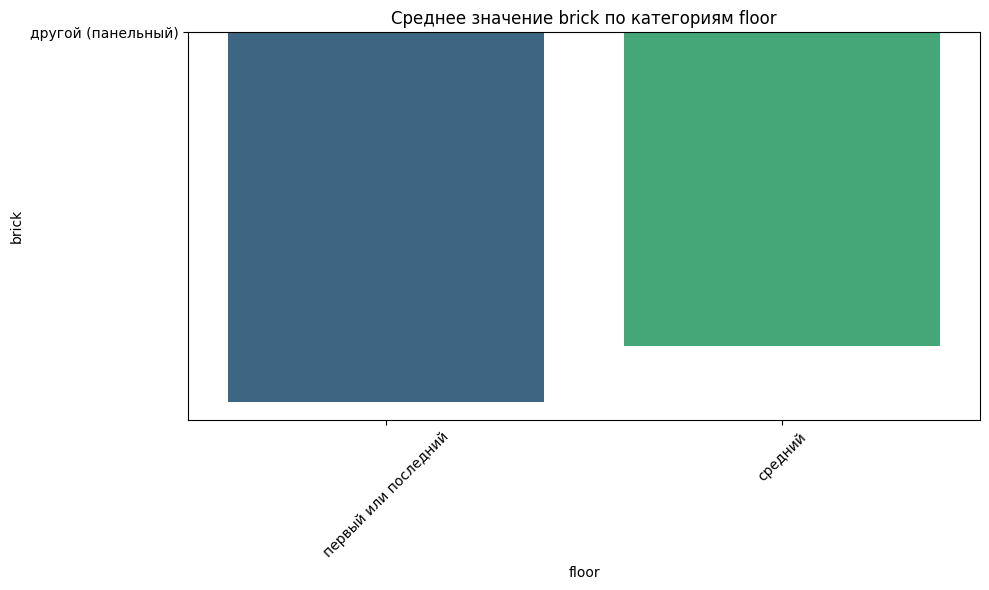

In [40]:
# 1. Распределение числового признака (автоматически построилась гистограмма)
# plot_universal(df_clean, 'price_m2')

# 2. Распределение категориального признака (автоматически построился barplot)
# plot_universal(df_clean, 'area')

# 3. Зависимость двух числовых признаков (автоматически построился scatter)
# plot_universal(df_clean, 'totsp', 'price_m2')

# 4. Зависимость числового признака от категориального (автоматически построился boxplot)
# plot_universal(df_clean, 'area', 'price_m2')

plot_universal(df_clean, 'floor', 'brick')

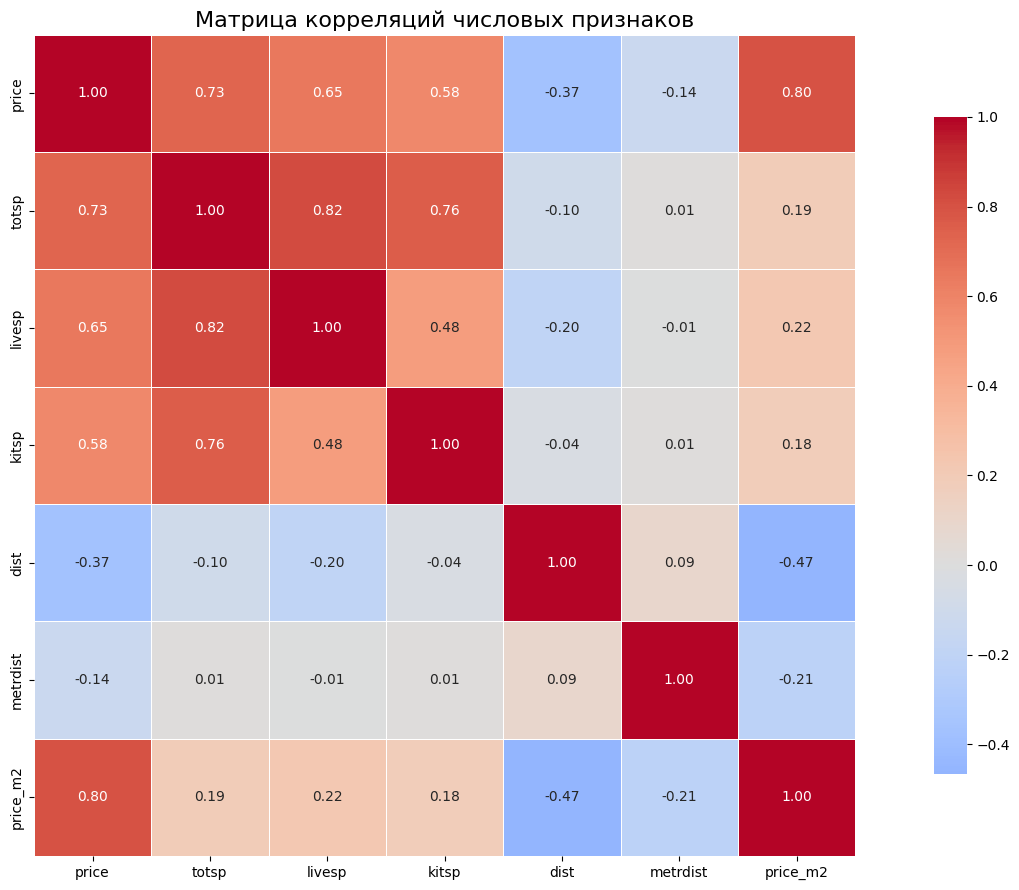

In [30]:
def plot_correlation_matrix(df):
    
    # отбор только числовых столбцов
    num_df = df.select_dtypes(include=[np.number])
    corr_matrix = num_df.corr()
    
    plt.figure(figsize=(16, 9))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title("Матрица корреляций числовых признаков", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return corr_matrix

# Вызов функции для очищенного датасета
corr_matrix = plot_correlation_matrix(df_clean)